# Quantus Focus — smoke test and validation

This notebook builds randomly sampled 2×2 mosaics in which the same target-class image appears twice and the other two images come from classes different from the target. It evaluates Quantus Focus on input-attribution relevance and displays the mosaics, target-position masks, scores, and relevance maps.

In [16]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

while not Path("lib").exists() and Path.cwd().parent != Path.cwd():
    os.chdir("..")

import numpy as np
import pandas as pd
import quantus
import torch

from evaluate_focus import (
    EXPLAINER_NAMES,
    build_focus_mosaics,
    format_positions,
    index_dataset_by_class,
    positions_to_masks,
    seed_everything,
)
from lib.defaults import get_default_kwargs
from lib.evaluator import default_explainers
from lib.helpers import plot_example_grid
from lib.setup import setup_notebook
from lib.surrogates import soften_module_inplace_

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

The smoke test uses Imagenette for speed. Set `DATASET` to `imagenet` before running the full experiment.

In [17]:
MODEL_NAME = "resnet50"
MODEL_SOURCE = "torchvision"
DATASET = "imagenette"
N_MOSAICS = 4
SEED = 314

seed_everything(SEED)

## Model, data, and mosaics

In [18]:
device, loader, model = setup_notebook(
    batch_size=1,
    model_name=MODEL_NAME,
    model_source=MODEL_SOURCE,
    seed=SEED,
    dataset=DATASET,
)
temperatures, _, _, _ = get_default_kwargs()
soften_module_inplace_(
    model,
    temperatures=temperatures,
    standard_backward=False,
    fill_default_temperatures=True,
)

dataset = loader.dataset
class_to_indices = index_dataset_by_class(dataset)
mosaics = build_focus_mosaics(
    dataset,
    class_to_indices,
    n_mosaics=N_MOSAICS,
    rng=np.random.default_rng(SEED),
)

print("device:", device)
print("dataset size:", len(dataset))
print("available classes:", len(class_to_indices))
print("mosaics:", mosaics.images.shape)
print("targets:", mosaics.targets.tolist())

/Users/msat/.venvs/quantus/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/msat/.venvs/quantus/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


device: mps
dataset size: 3925
available classes: 10
mosaics: (4, 3, 448, 448)
targets: [497, 217, 566, 574]


In [19]:
if MODEL_NAME.startswith("resnet"):
    gc_layer = model[1].layer4[-1].conv3
elif MODEL_NAME.startswith("vgg"):
    gc_layer = model[1].avgpool
elif MODEL_NAME.startswith("pvt"):
    # gc_layer = model[1].stages[-1].blocks[-1].mlp
    gc_layer = None

## Validate mosaic construction

In `source_indices`, the target image index must appear exactly twice at the positions marked with ones. Labels in the remaining positions must differ from the target.

In [20]:
metadata_rows = []
for index, (target, positions, component_labels, source_indices) in enumerate(
    zip(
        mosaics.targets,
        mosaics.positions,
        mosaics.component_labels,
        mosaics.source_indices,
    )
):
    target_source_indices = [
        source_index
        for source_index, is_target in zip(source_indices, positions)
        if is_target
    ]
    assert len(target_source_indices) == 2
    assert target_source_indices[0] == target_source_indices[1]
    assert all(
        label == target if is_target else label != target
        for label, is_target in zip(component_labels, positions)
    )
    metadata_rows.append(
        {
            "mosaic": index,
            "target": int(target),
            "target_positions": format_positions(positions),
            "component_labels": tuple(component_labels),
            "source_indices": tuple(source_indices),
        }
    )

metadata_df = pd.DataFrame(metadata_rows)
display(metadata_df)

,mosaic,target,target_positions,component_labels,source_indices
0,0,497,"bottom_left,bottom_right","(701, 571, 497, 497)","(3753, 3032, 1816, 1816)"
1,1,217,"top_left,top_right","(217, 217, 491, 491)","(743, 743, 1238, 1297)"
2,2,566,"top_left,bottom_left","(566, 497, 566, 571)","(2073, 1599, 2073, 3006)"
3,3,574,"top_right,bottom_left","(566, 574, 574, 566)","(2284, 3374, 3374, 2005)"


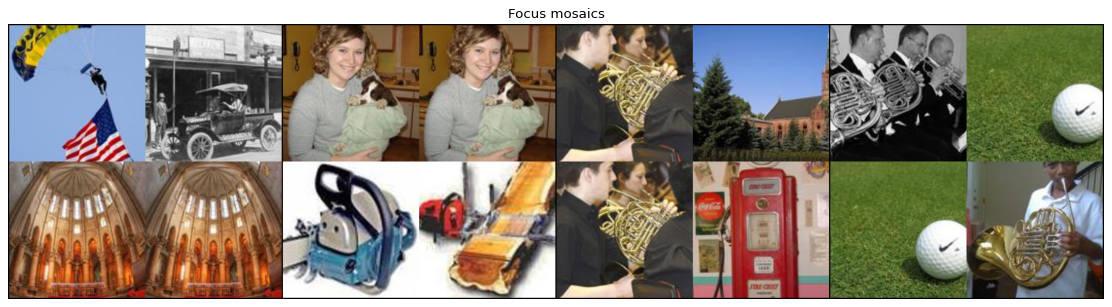

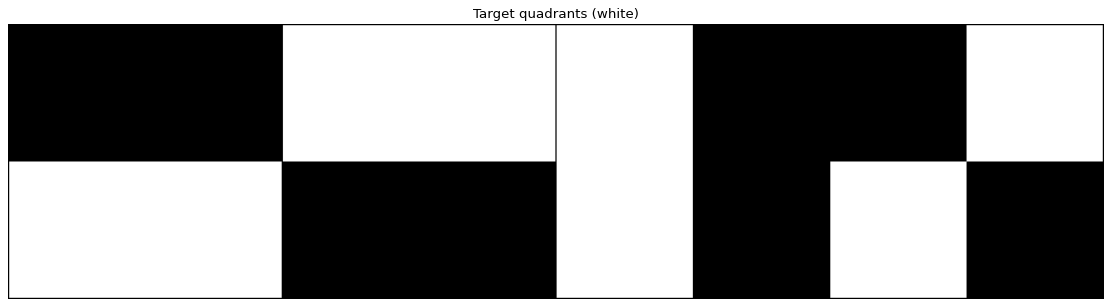

In [21]:
plot_example_grid(
    torch.from_numpy(mosaics.images),
    nrow=4,
    title="Focus mosaics",
)

target_masks = positions_to_masks(mosaics.positions, mosaics.images.shape)
plot_example_grid(
    torch.from_numpy(target_masks),
    nrow=4,
    normalize=False,
    value_range=(0, 1),
    cmap="gray",
    title="Target quadrants (white)",
)

## Attributions and Focus

The notebook first computes `relevance = input * attribution`. The standard Quantus Focus metric then retains positive relevance and measures the share located in the two target quadrants. No absolute value or additional normalisation is applied.

In [22]:
explainers = default_explainers(EXPLAINER_NAMES, gc_layer=gc_layer)
attributions = {}
relevances = {}

for explainer_name, (explain_func, explain_kwargs) in explainers.items():
    print(f"Computing {explainer_name}...")
    attributions[explainer_name] = explain_func(
        model,
        mosaics.images,
        mosaics.targets,
        device=device,
        **explain_kwargs,
    )
    relevances[explainer_name] = mosaics.images * attributions[explainer_name]
    print(explainer_name, attributions[explainer_name].shape)

Computing PullbackAscent...
PullbackAscent (4, 3, 448, 448)
Computing SoftPullback...
SoftPullback (4, 3, 448, 448)
Computing Gradient...
Gradient (4, 3, 448, 448)
Computing GradientAscent...
GradientAscent (4, 3, 448, 448)
Computing GuidedGradCam...


/Users/msat/.venvs/quantus/lib/python3.14/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


GuidedGradCam (4, 3, 448, 448)


In [23]:
metric = quantus.Focus(
    abs=False,
    normalise=False,
    return_aggregate=False,
    disable_warnings=True,
)
score_rows = []
for explainer_name, relevance in relevances.items():
    metric_scores = np.asarray(
        metric(
            model=model,
            x_batch=mosaics.images,
            y_batch=mosaics.targets,
            a_batch=relevance,
            custom_batch=mosaics.positions,
            channel_first=True,
            device=device,
        )
    )
    for mosaic_index, score in enumerate(metric_scores):
        score_rows.append(
            {
                "explainer": explainer_name,
                "mosaic": mosaic_index,
                "target": int(mosaics.targets[mosaic_index]),
                "positions": format_positions(mosaics.positions[mosaic_index]),
                "focus": float(score),
            }
        )

scores_df = pd.DataFrame(score_rows)
display(scores_df)
display(scores_df.groupby("explainer")["focus"].agg(["mean", "std", "count"]))

,explainer,mosaic,target,positions,focus
0,PullbackAscent,0,497,"bottom_left,bottom_right",0.712641
1,PullbackAscent,1,217,"top_left,top_right",0.716217
2,PullbackAscent,2,566,"top_left,bottom_left",0.867712
3,PullbackAscent,3,574,"top_right,bottom_left",0.643927
4,SoftPullback,0,497,"bottom_left,bottom_right",0.741654
5,SoftPullback,1,217,"top_left,top_right",0.786672
6,SoftPullback,2,566,"top_left,bottom_left",0.858225
7,SoftPullback,3,574,"top_right,bottom_left",0.702560
8,Gradient,0,497,"bottom_left,bottom_right",0.424939
9,Gradient,1,217,"top_left,top_right",0.599526


,mean,std,count
explainer,,,
Gradient,0.611904,0.173969,4
GradientAscent,0.559038,0.150772,4
GuidedGradCam,0.955209,0.048137,4
PullbackAscent,0.735124,0.094445,4
SoftPullback,0.772277,0.066814,4


## Attribution visualisation

A good explanation should concentrate positive input-attribution relevance in the two target quadrants shown in white above.

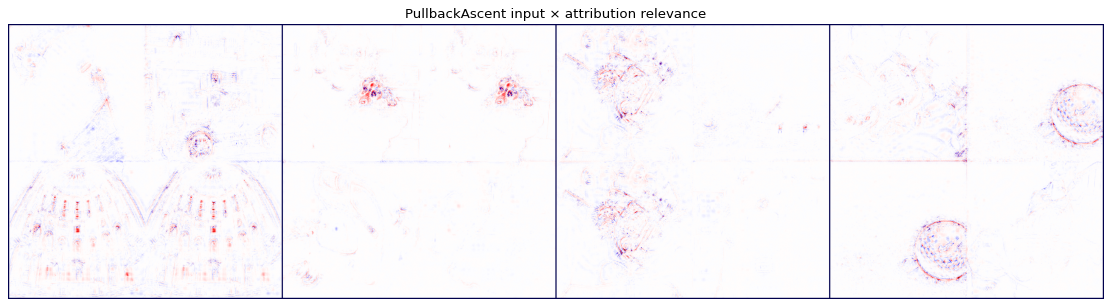

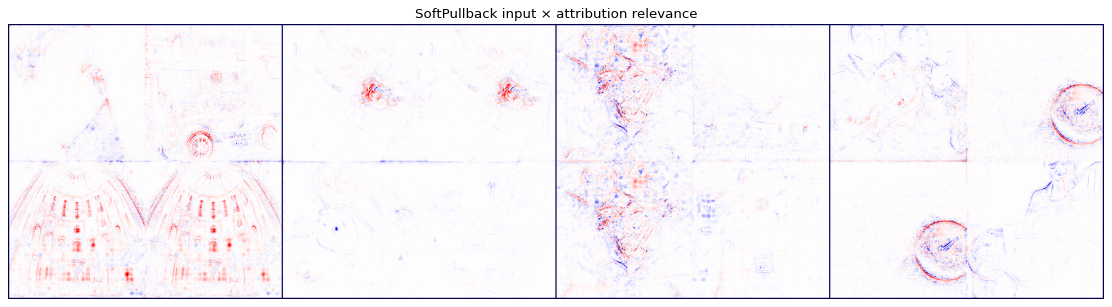

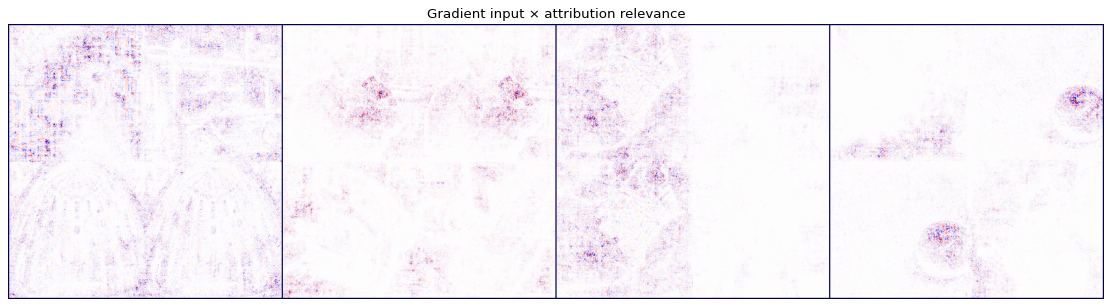

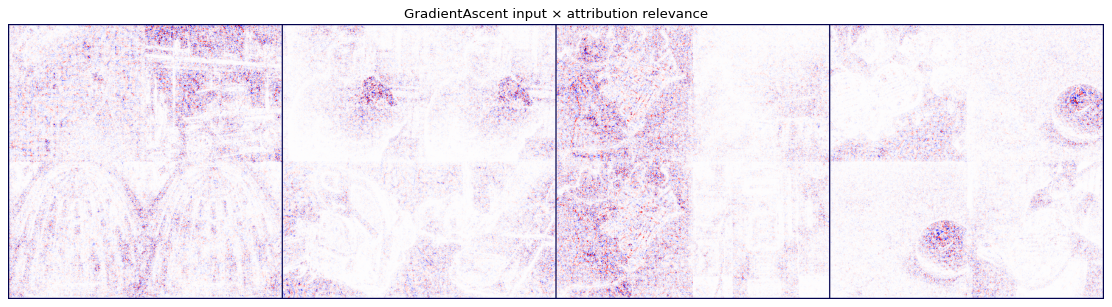

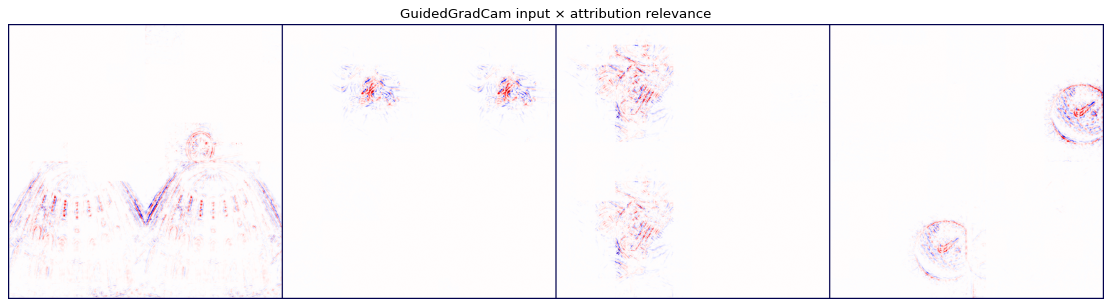

In [24]:
for explainer_name, relevance in relevances.items():
    plot_example_grid(
        torch.from_numpy(relevance),
        nrow=4,
        heatmap=True,
        heatmap_mode="sum",
        title=f"{explainer_name} input × attribution relevance",
    )